In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM = 42

In [2]:
mice = pd.read_excel('Data_Cortex_Nuclear.xls')
mice.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [3]:
mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]
mice['mouse_id'].describe()

count     1080
unique      72
top        309
freq        15
Name: mouse_id, dtype: object

In [4]:
mice.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N          1077 non

In [5]:
print("Mouse_IDs unique:", mice["MouseID"].is_unique)
mice = mice.set_index('MouseID')

Mouse_IDs unique: True


In [6]:
gene_cols = mice.columns[1:-5]
mice[gene_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
ITSN1_N,1077.0,0.617102,0.251640,0.245359,0.473361,0.565782,0.698032,2.602662
BDNF_N,1077.0,0.319088,0.049383,0.115181,0.287444,0.316564,0.348197,0.497160
NR1_N,1077.0,2.297269,0.347293,1.330831,2.057411,2.296546,2.528481,3.757641
NR2A_N,1077.0,3.843934,0.933100,1.737540,3.155678,3.760855,4.440011,8.482553
pAKT_N,1077.0,0.233168,0.041634,0.063236,0.205755,0.231177,0.257261,0.539050
pBRAF_N,1077.0,0.181846,0.027042,0.064043,0.164595,0.182302,0.197418,0.317066
pCAMKII_N,1077.0,3.537109,1.295169,1.343998,2.479834,3.326520,4.481940,7.464070
pCREB_N,1077.0,0.212574,0.032587,0.112812,0.190823,0.210594,0.234595,0.306247
pELK_N,1077.0,1.428682,0.466904,0.429032,1.203665,1.355846,1.561316,6.113347
pERK_N,1077.0,0.545904,0.345309,0.149155,0.337405,0.443644,0.663297,3.566685


In [7]:
na_per_row = mice[gene_cols].isna().sum(axis=1)
display(na_per_row.sort_values(ascending=False).head())

invalid_mice = na_per_row > 40

mice = mice[~invalid_mice]
mice.shape

MouseID
3426_15      42
3426_14      42
3426_13      42
50810F_6      5
50810F_12     5
dtype: int64

(1077, 82)

In [8]:
na_genes = mice[gene_cols].isna().sum()
filter_out = na_genes[na_genes > 100]
filter_out.head()

BAD_N        213
BCL2_N       285
H3AcK18_N    180
EGR1_N       210
H3MeK4_N     270
dtype: int64

In [9]:
imputer = SimpleImputer(strategy="median")
x_imputed = pd.DataFrame(imputer.fit_transform(mice[gene_cols]), columns=gene_cols)
x_imputed.isna().sum().sum()

np.int64(0)

In [10]:
means = x_imputed.mean()
variances = x_imputed.var()

print("Constant features:", (variances == 0).sum())
print("Median feature variance:", variances.median())

Constant features: 0
Median feature variance: 0.004355947638111202


In [11]:
display(means.head())
display(variances.head())

ITSN1_N    0.617102
BDNF_N     0.319088
NR1_N      2.297269
NR2A_N     3.843934
pAKT_N     0.233168
dtype: float64

ITSN1_N    0.063323
BDNF_N     0.002439
NR1_N      0.120612
NR2A_N     0.870676
pAKT_N     0.001733
dtype: float64

/var/folders/m7/qn99csmd48s9232z_r7d50nw0000gn/T/ipykernel_44456/797100276.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


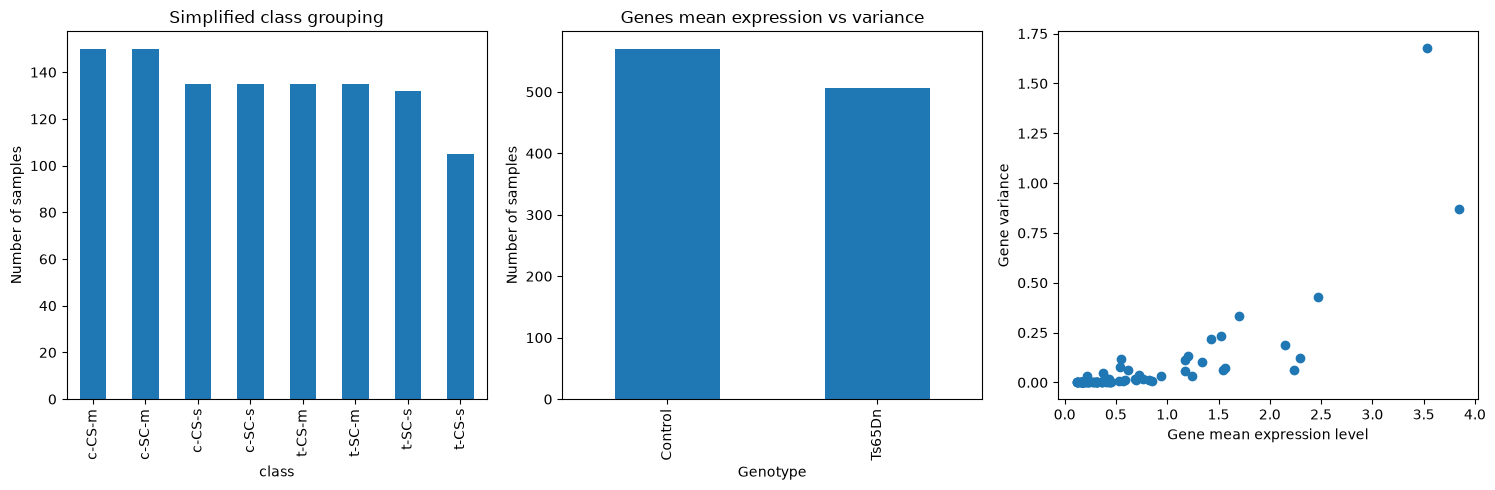

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

mice["class"].value_counts().plot(kind="bar", ax=axs[0])
axs[0].set_ylabel("Number of samples")
axs[0].set_title("Simplified class grouping")

mice["Genotype"].value_counts().plot(kind="bar", ax=axs[1])
axs[1].set_ylabel("Number of samples")
axs[1].set_title("Simplified genotype grouping")

axs[2].scatter(means, variances)
axs[2].set_xlabel("Gene mean expression level")
axs[2].set_ylabel("Gene variance")
axs[1].set_title("Genes mean expression vs variance")

fig.tight_layout()
fig.savefig('plots/mice_eda.png')
fig.show()

In [13]:
X_scaled = StandardScaler().fit_transform(x_imputed)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "Genotype": mice["Genotype"].astype(str).values,
    "Treatment": mice["Treatment"].astype(str).values,
    "Behavior": mice["Behavior"].astype(str).values,
    "class": mice["class"].astype(str).values,
    "mouse_id": mice["mouse_id"].astype(str).values,
})

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

Explained variance: [0.256 0.166]


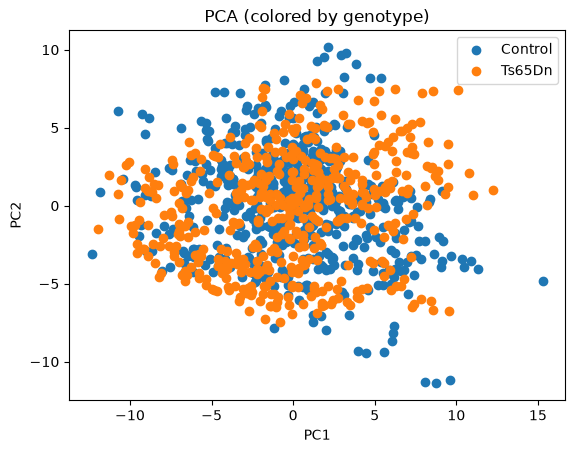

In [14]:
for genotype, group in pca_df.groupby("Genotype"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=genotype
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (colored by genotype)")
plt.savefig('plots/mice_pca.png')
plt.legend()
plt.show()

In [15]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM)

train_idx, test_idx = next(
    splitter.split(
        mice[gene_cols],
        mice["Genotype"],
        groups=mice["mouse_id"]))

train_df = mice.iloc[train_idx].copy()
test_df = mice.iloc[test_idx].copy()

train_groups = set(train_df["mouse_id"])
test_groups = set(test_df["mouse_id"])

print("Group overlap", train_groups & test_groups)

Group overlap set()
